In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from PIL import Image

In [5]:
df = pd.read_csv("../dataset/HAM10000_metadata.csv")

In [6]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [8]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [9]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

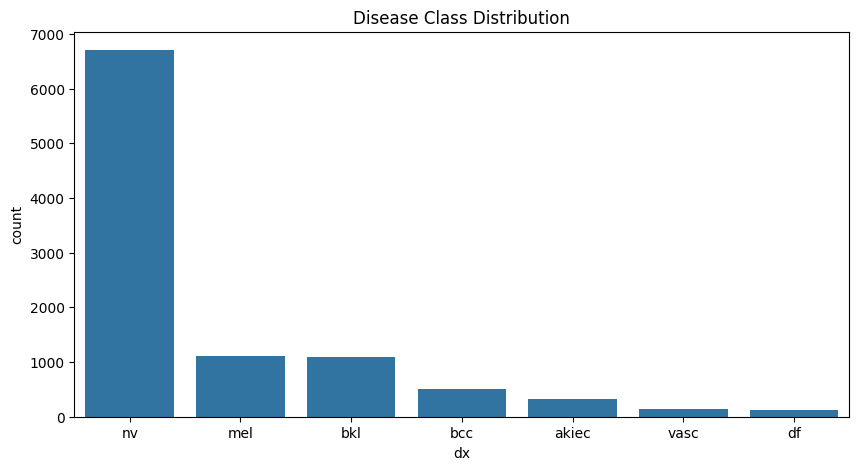

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=df["dx"],
    order=df["dx"].value_counts().index
)

plt.title("Disease Class Distribution")
plt.show()

In [11]:
df["sex"].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

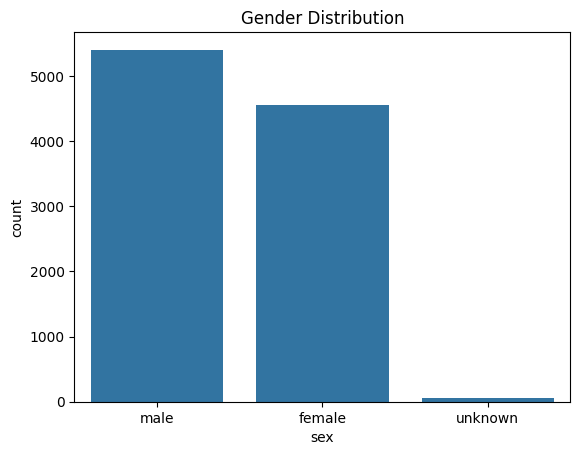

In [12]:
sns.countplot(x=df["sex"])

plt.title("Gender Distribution")

plt.show()

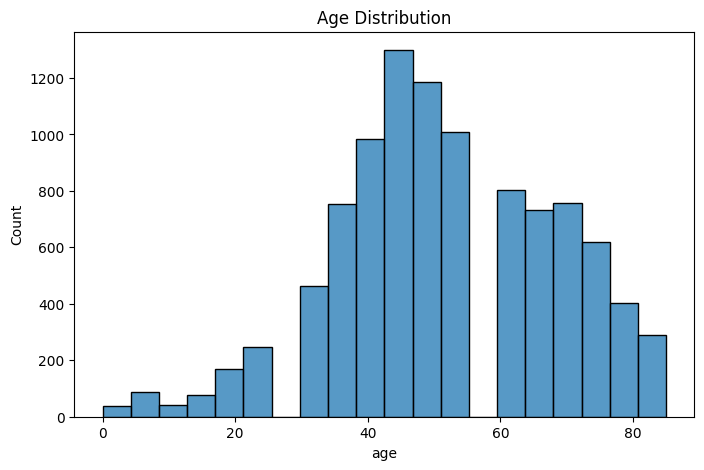

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20
)

plt.title("Age Distribution")

plt.show()

In [14]:
df["localization"].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

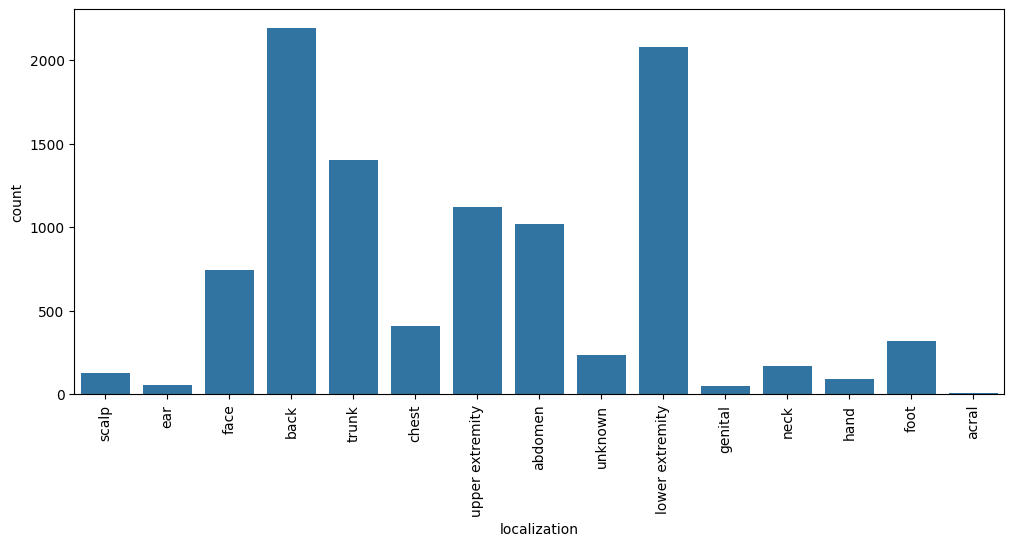

In [15]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=df["localization"]
)

plt.xticks(rotation=90)

plt.show()

In [18]:
import os

image_dir1 = "../dataset/HAM10000_images_part_1"
image_dir2 = "../dataset/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir1, image_dir2]:

    for file in os.listdir(folder):

        image_paths[file.split(".")[0]] = os.path.join(folder,file)

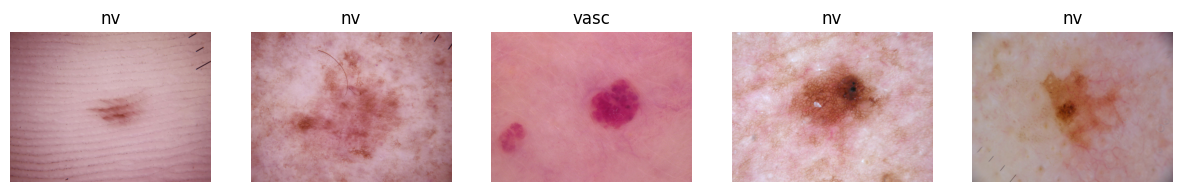

In [19]:
sample = df.sample(5)

plt.figure(figsize=(15,5))

for i,row in enumerate(sample.itertuples()):

    img = Image.open(
        image_paths[row.image_id]
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(row.dx)

    plt.axis("off")

plt.show()

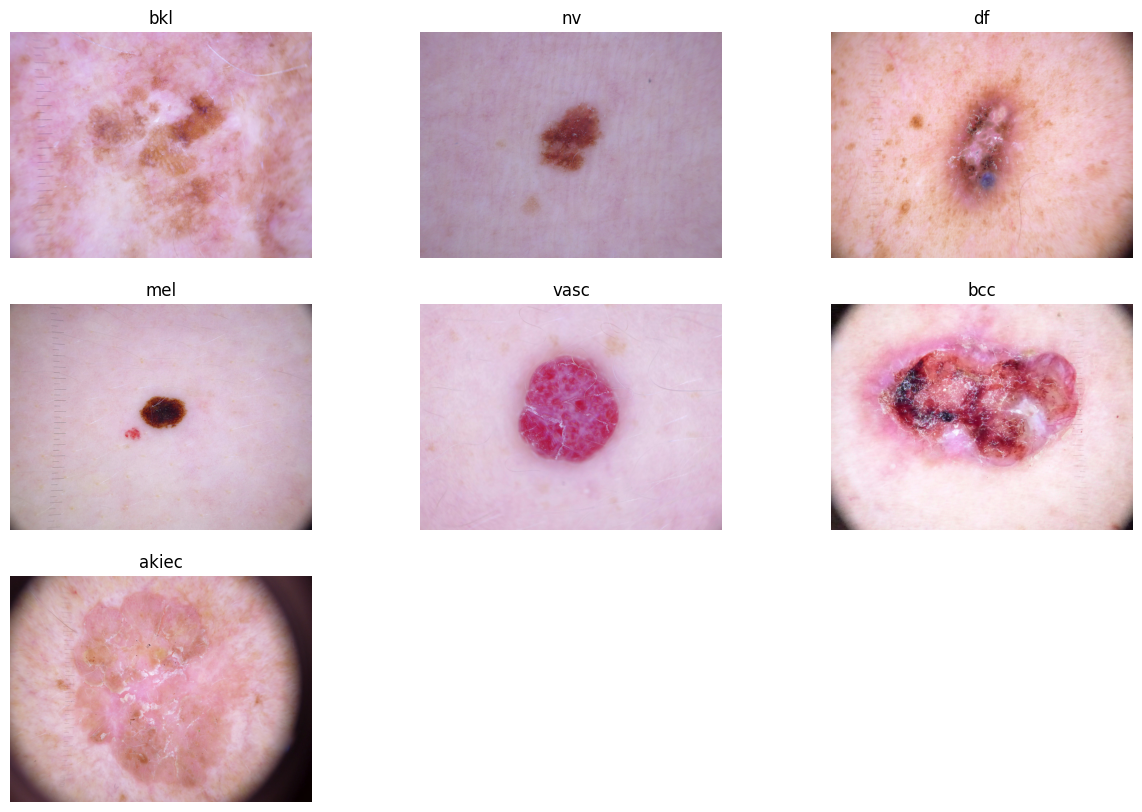

In [20]:
classes = df["dx"].unique()

plt.figure(figsize=(15,10))

for i,cls in enumerate(classes):

    image_id = df[df["dx"]==cls].iloc[0]["image_id"]

    img = Image.open(
        image_paths[image_id]
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.show()

# Observations

1. Dataset contains 7 skin lesion classes.

2. Significant class imbalance exists.

3. Melanocytic Nevus (nv) is the majority class.

4. Dermatofibroma (df) has the fewest samples.

5. Most patients are middle-aged adults.

6. Lesions occur predominantly on the trunk and lower extremities.